# Week 06: Business Statistics & Analytics - E-commerce Analysis

## Learning Objectives
By the end of this exercise, you will be able to:
- Calculate key business metrics using pandas
- Create meaningful visualizations for business insights
- Apply statistical concepts to real business scenarios
- Make data-driven recommendations

---

## Business Context

You're working as a Data Analyst for **TechMart**, an e-commerce company. Your manager needs insights from last quarter's sales data to inform strategic decisions for the upcoming quarter.

Your analysis will help answer critical questions about customer behavior, regional performance, and product trends that directly impact business growth.

## Dataset Setup

First, let's generate the synthetic dataset you'll be analyzing:

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducible results
np.random.seed(42)

# Generate 500 orders from 2023
n_orders = 500

# Create order IDs and customer data
order_id = np.arange(1, n_orders + 1)
customer_id = np.random.randint(1, 101, size=n_orders)
customer_segment = np.random.choice(["Student", "Professional", "Senior"], size=n_orders, p=[0.4, 0.4, 0.2])
region = np.random.choice(["North", "South", "East", "West"], size=n_orders)
order_date = pd.date_range(start="2023-01-01", periods=n_orders, freq="D")
product_category = np.random.choice(["Electronics", "Clothing", "Books", "Home", "Sports"], size=n_orders)
quantity = np.random.randint(1, 5, size=n_orders)
unit_price = np.round(np.random.uniform(10, 200, size=n_orders), 2)
revenue = quantity * unit_price
discount_applied = np.random.choice([0, 5, 10, 15, 20, 25, 30], size=n_orders, p=[0.5,0.1,0.1,0.1,0.05,0.05,0.1])
payment_method = np.random.choice(["Credit Card", "PayPal", "Gift Card", "Debit Card"], size=n_orders)

# Build dataframe
df = pd.DataFrame({
    "order_id": order_id,
    "customer_id": customer_id,
    "customer_segment": customer_segment,
    "region": region,
    "order_date": order_date,
    "product_category": product_category,
    "quantity": quantity,
    "unit_price": unit_price,
    "revenue": revenue,
    "discount_applied": discount_applied,
    "payment_method": payment_method
})

# Save dataset for reference
df.to_csv("ecommerce_data.csv", index=False)
print("✅ Dataset created successfully!")

# Display first few rows
df.head()

✅ Dataset created successfully!


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


## Data Exploration

Let's start by understanding our dataset:

In [4]:
# Load the data
data = pd.read_csv("ecommerce_data.csv")

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
data.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   customer_segment  500 non-null    object 
 3   region            500 non-null    object 
 4   order_date        500 non-null    object 
 5   product_category  500 non-null    object 
 6   quantity          500 non-null    int64  
 7   unit_price        500 non-null    float64
 8   revenue           500 non-null    float64
 9   discount_applied  500 non-null    int64  
 10  payment_method    500 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Dataset Shape: (500, 11)

First few rows:


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


Monthly Revenue:
month
2023-01    6626.66
2023-02    6796.03
2023-03    8960.10
2023-04    7713.47
2023-05    7266.80
2023-06    7982.47
2023-07    7981.65
2023-08    6664.64
2023-09    9708.06
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


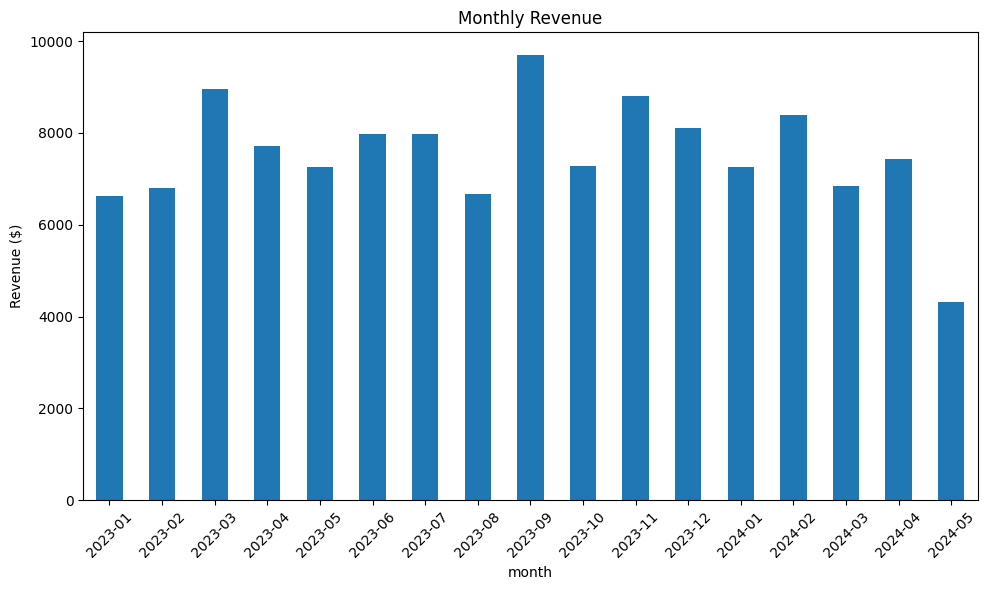

In [5]:
# Convert order_date to datetime and add helpful columns
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["day_of_week"] = data["order_date"].dt.day_name()

# Example: Revenue by month
monthly_revenue = data.groupby("month")["revenue"].sum()
print("Monthly Revenue:")
print(monthly_revenue)

# Plot monthly revenue
monthly_revenue.plot(kind="bar", figsize=(10,6), title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Business Questions

Now answer each of the following business questions. Use the starter code above as a reference, and expand your analysis to solve all questions.

### 1. Revenue Overview
What was the company's total revenue last quarter? Break it down by month.

In [6]:
# Your code here

# Define the months in the last quarter
last_quarter = ["2024-03", "2024-04", "2024-05"]

# Get the specific months from the monthly revenue
last_quarter_revenue = monthly_revenue[last_quarter]

# Print breakdown
print("Last Quarter Revenue by Month:")
print(last_quarter_revenue.sort_values(ascending=False))

# Total
total_last_quarter = last_quarter_revenue.sum()
print(f"\n✅ Total Revenue Last Quarter: ${total_last_quarter:,.2f}")


Last Quarter Revenue by Month:
month
2024-04    7430.29
2024-03    6835.73
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64

✅ Total Revenue Last Quarter: $18,580.73


### 2. Top Customers
Who are the top 5 customers by total revenue contribution?

Top 5 Customers:
customer_id
62    4448.39
24    3369.44
90    2976.78
92    2838.74
97    2835.62
Name: revenue, dtype: float64


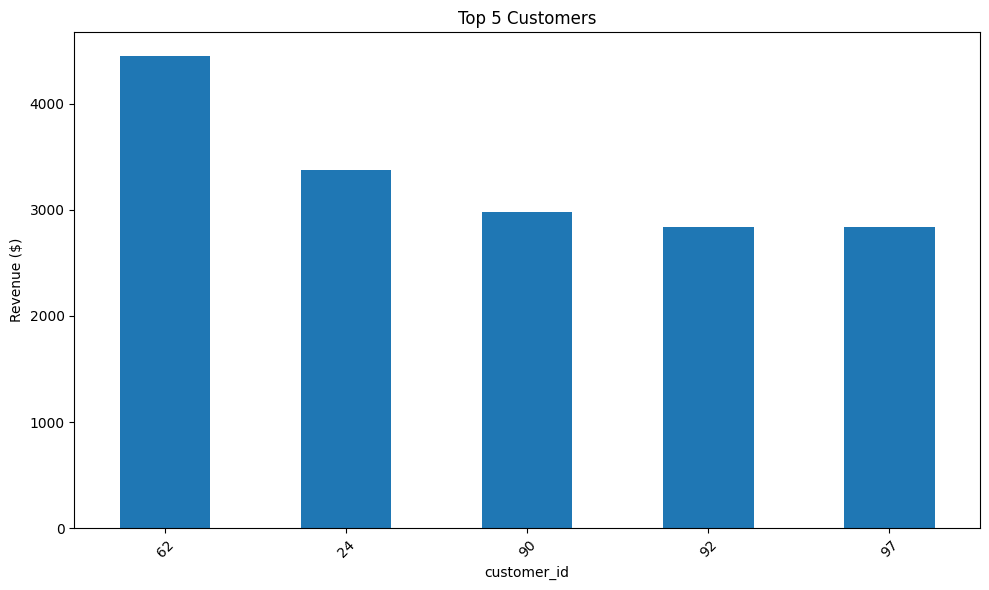

In [8]:
# Your code here

# Example: Revenue by customer
top_five = data.groupby("customer_id")["revenue"].sum()
# Sort descending and get top 5
top_five = top_five.sort_values(ascending=False).head(5)

print("Top 5 Customers:")
print(top_five)

top_five.plot(kind="bar", figsize=(10,6), title="Top 5 Customers")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Segment Analysis
Which customer segment (Student, Professional, Senior) spends the most on average per order?

Average price Order for segment:
customer_segment
Senior          262.133925
Professional    255.652674
Student         253.812087
Name: revenue, dtype: float64


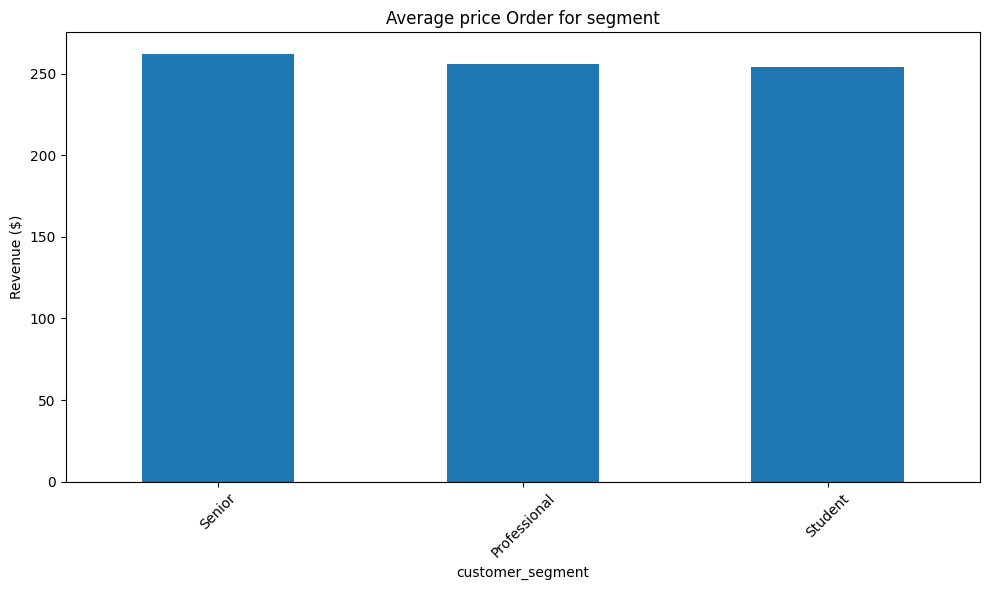

In [9]:
# Your code here

# Example: Revenue by segment
segment = data.groupby("customer_segment")["revenue"].mean()
# Sort descending and get top 5
segment = segment.sort_values(ascending=False)

print("Average price Order for segment:")
print(segment)

segment.plot(kind="bar", figsize=(10,6), title="Average price Order for segment")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4. Regional Trends
Which region generated the highest revenue? Which region had the highest average order size?

Highest average order size for the 4 regions
region
West    2.627273
Name: quantity, dtype: float64
Highest Revenue Per Region:
region
South    34839.45
North    34351.69
East     31221.80
West     27727.73
Name: revenue, dtype: float64


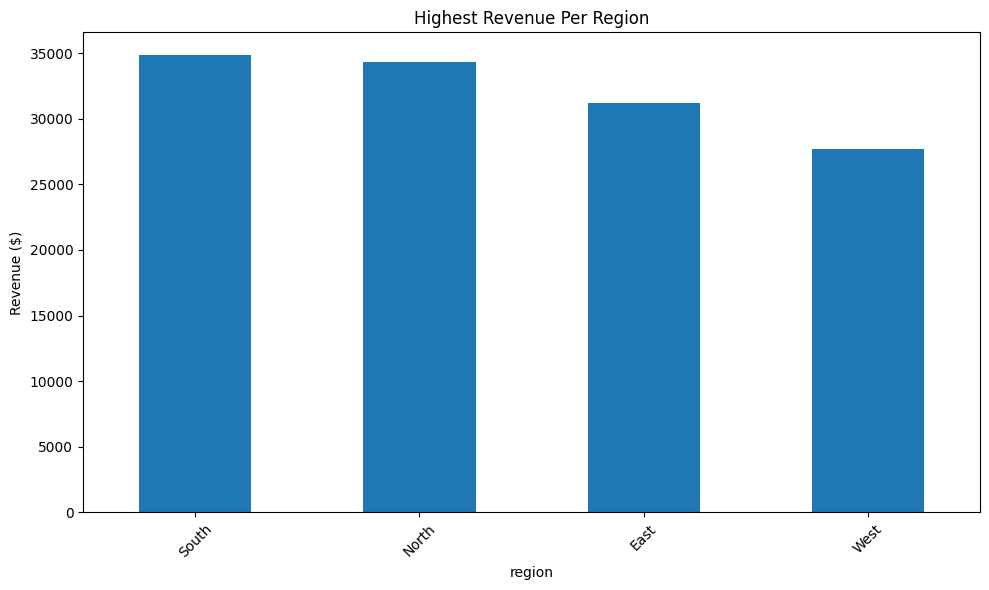

In [12]:
# Your code here

# Example: Revenue by segment
high_region = data.groupby("region")["revenue"].sum()
# Sort descending 
high_region = high_region.sort_values(ascending=False)

high_region_average = data.groupby("region")["quantity"].mean()
high_region_average = high_region_average.sort_values(ascending=False).head(1)
print("Highest average order size for the 4 regions")
print(high_region_average)

print("Highest Revenue Per Region:")
print(high_region)

high_region.plot(kind="bar", figsize=(10,6), title="Highest Revenue Per Region")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Product Category Performance
Which product category is most popular by quantity vs. by revenue?

In [8]:
# Your code here
product_revenue = data.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
product_quantity = data.groupby("product_category")["quantity"].sum().sort_values(ascending=False)

# Combine both into one DataFrame
product_summary = pd.DataFrame({
    "Total Revenue": product_revenue,
    "Total Quantity": product_quantity
})

# Sort by revenue (or any other column)
product_summary = product_summary.sort_values(by="Total Revenue", ascending=False)

# Display the combined table
print("📦 Product Category Summary:")
print(product_summary)

📦 Product Category Summary:
                  Total Revenue  Total Quantity
product_category                               
Home                   29871.47             269
Electronics            25498.31             239
Clothing               24804.57             253
Books                  24046.06             227
Sports                 23920.26             246


### 6. Discount Effectiveness
Do discounted orders generate higher or lower revenue per order compared to non-discounted orders?

Discounted vs Non-Discounted orders
discount_applied
0     60336.01
5     15747.94
15    13906.68
10    11639.38
30    10780.34
25     9040.83
20     6689.49
Name: revenue, dtype: float64


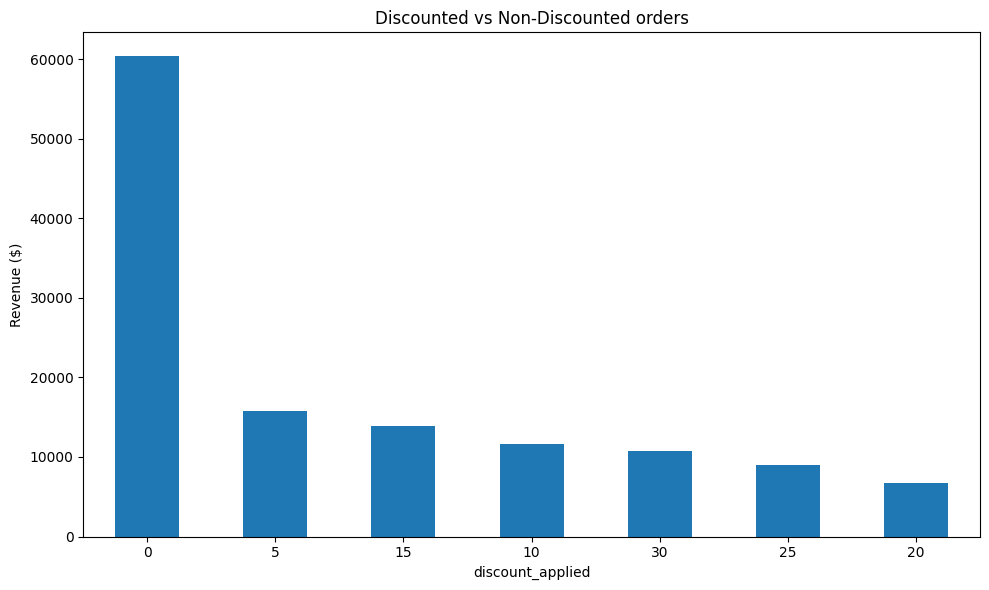

In [15]:
# Your code here
product_revenue = data.groupby("discount_applied")["revenue"].sum().sort_values(ascending=False)
print("Discounted vs Non-Discounted orders")
product_revenue.reset_index()
print(product_revenue)

product_revenue.plot(kind="bar", figsize=(10,6), title="Discounted vs Non-Discounted orders")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7. Payment Method Usage
What percentage of orders use each payment method? Does any payment method correlate with higher spending?

📊 Payment Method Revenue (% of Total):
payment_method
Credit Card    27.52
Debit Card     26.49
Gift Card      24.61
PayPal         21.37
Name: revenue, dtype: float64


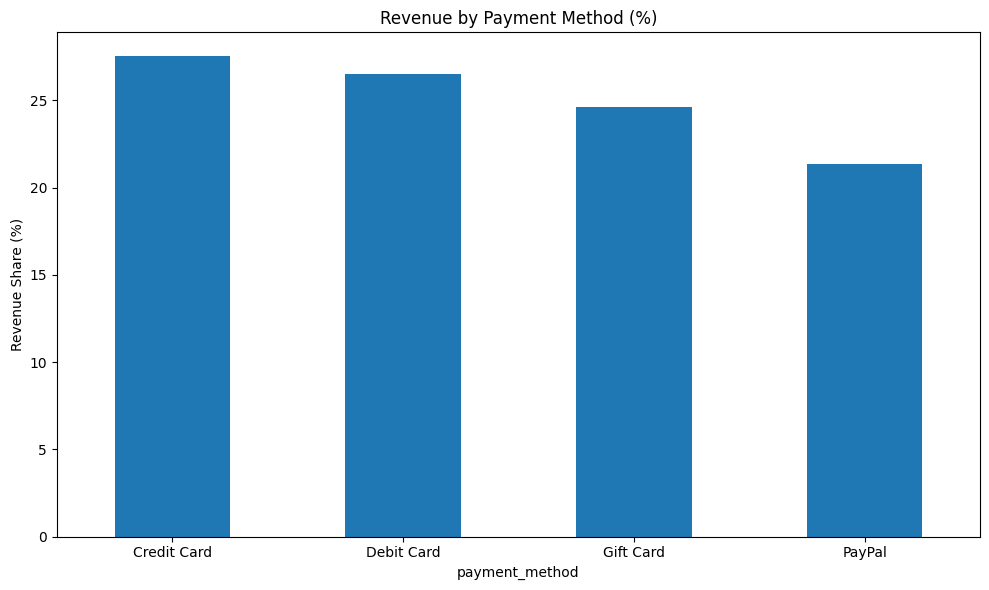

In [17]:
# Group revenue by payment method
pay_method = data.groupby("payment_method")["revenue"].sum()

# Calculate percentage of total revenue
pay_method_percent = (pay_method / pay_method.sum()) * 100

# Sort for better visualization
pay_method_percent = pay_method_percent.sort_values(ascending=False)

# Display
print("📊 Payment Method Revenue (% of Total):")
print(pay_method_percent.round(2))  # Round to 2 decimal places

# Optional: reset index if you want a DataFrame (not needed just to print)
# pay_method_percent_df = pay_method_percent.reset_index()

# Plot
pay_method_percent.plot(kind="bar", figsize=(10,6), title="Revenue by Payment Method (%)")
plt.ylabel("Revenue Share (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 8. Seasonality Check
Plot revenue by day of week — are weekends busier than weekdays?

In [18]:
data.head()

,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method,month,day_of_week
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card,2023-01,Sunday
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card,2023-01,Monday
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card,2023-01,Tuesday
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card,2023-01,Wednesday
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card,2023-01,Thursday


Revenue by Day of week
day_of_week
Tuesday      18968.41
Wednesday    18908.21
Saturday     18660.35
Friday       18522.40
Thursday     17846.36
Monday       17704.70
Sunday       17530.24
Name: revenue, dtype: float64


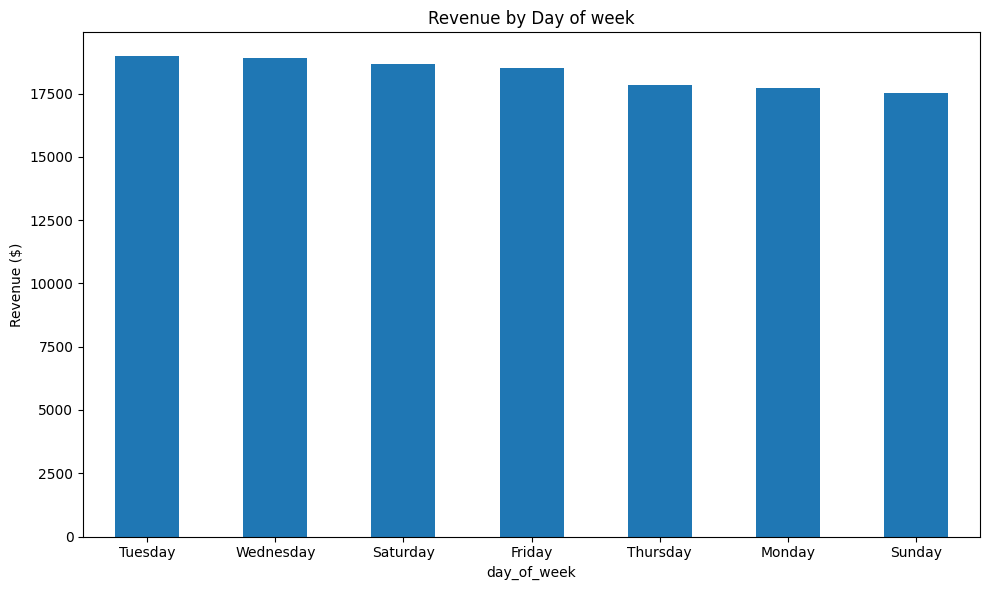

In [19]:
# Your code here
# Your code here
weekday = data.groupby("day_of_week")["revenue"].sum().sort_values(ascending=False)
print("Revenue by Day of week")
weekday.reset_index()
print(weekday)

weekday.plot(kind="bar", figsize=(10,6), title="Revenue by Day of week")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 9. Profitability (Stretch)
Assume profit margin = 20% of revenue. Estimate total profit and identify the most profitable region.

In [ ]:
# Your code here

### 10. Business Recommendation
Based on your findings, recommend one strategy (e.g., focus on certain customer segments, increase discounts, promote specific regions/products).

**Your recommendation here:**

Write your analysis and recommendation based on the insights you discovered from the data.

Since students were likely to spend less per order, I would suggest inreasing ads towards consumer in that bracket to encourage them to spend more.

---

## Submission Requirements

1. **Complete code** for all 10 questions
2. **Clear visualizations** where appropriate  
3. **Brief interpretation** of each result
4. **Final business recommendation** with supporting data

Remember: Focus on what the numbers tell us about the business, not just the calculations themselves.